In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
USAhousing = pd.read_csv("./house/USA_Housing.csv")
USAhousing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [ ]:
USAhousing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [ ]:
USAhousing.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [ ]:
USAhousing.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

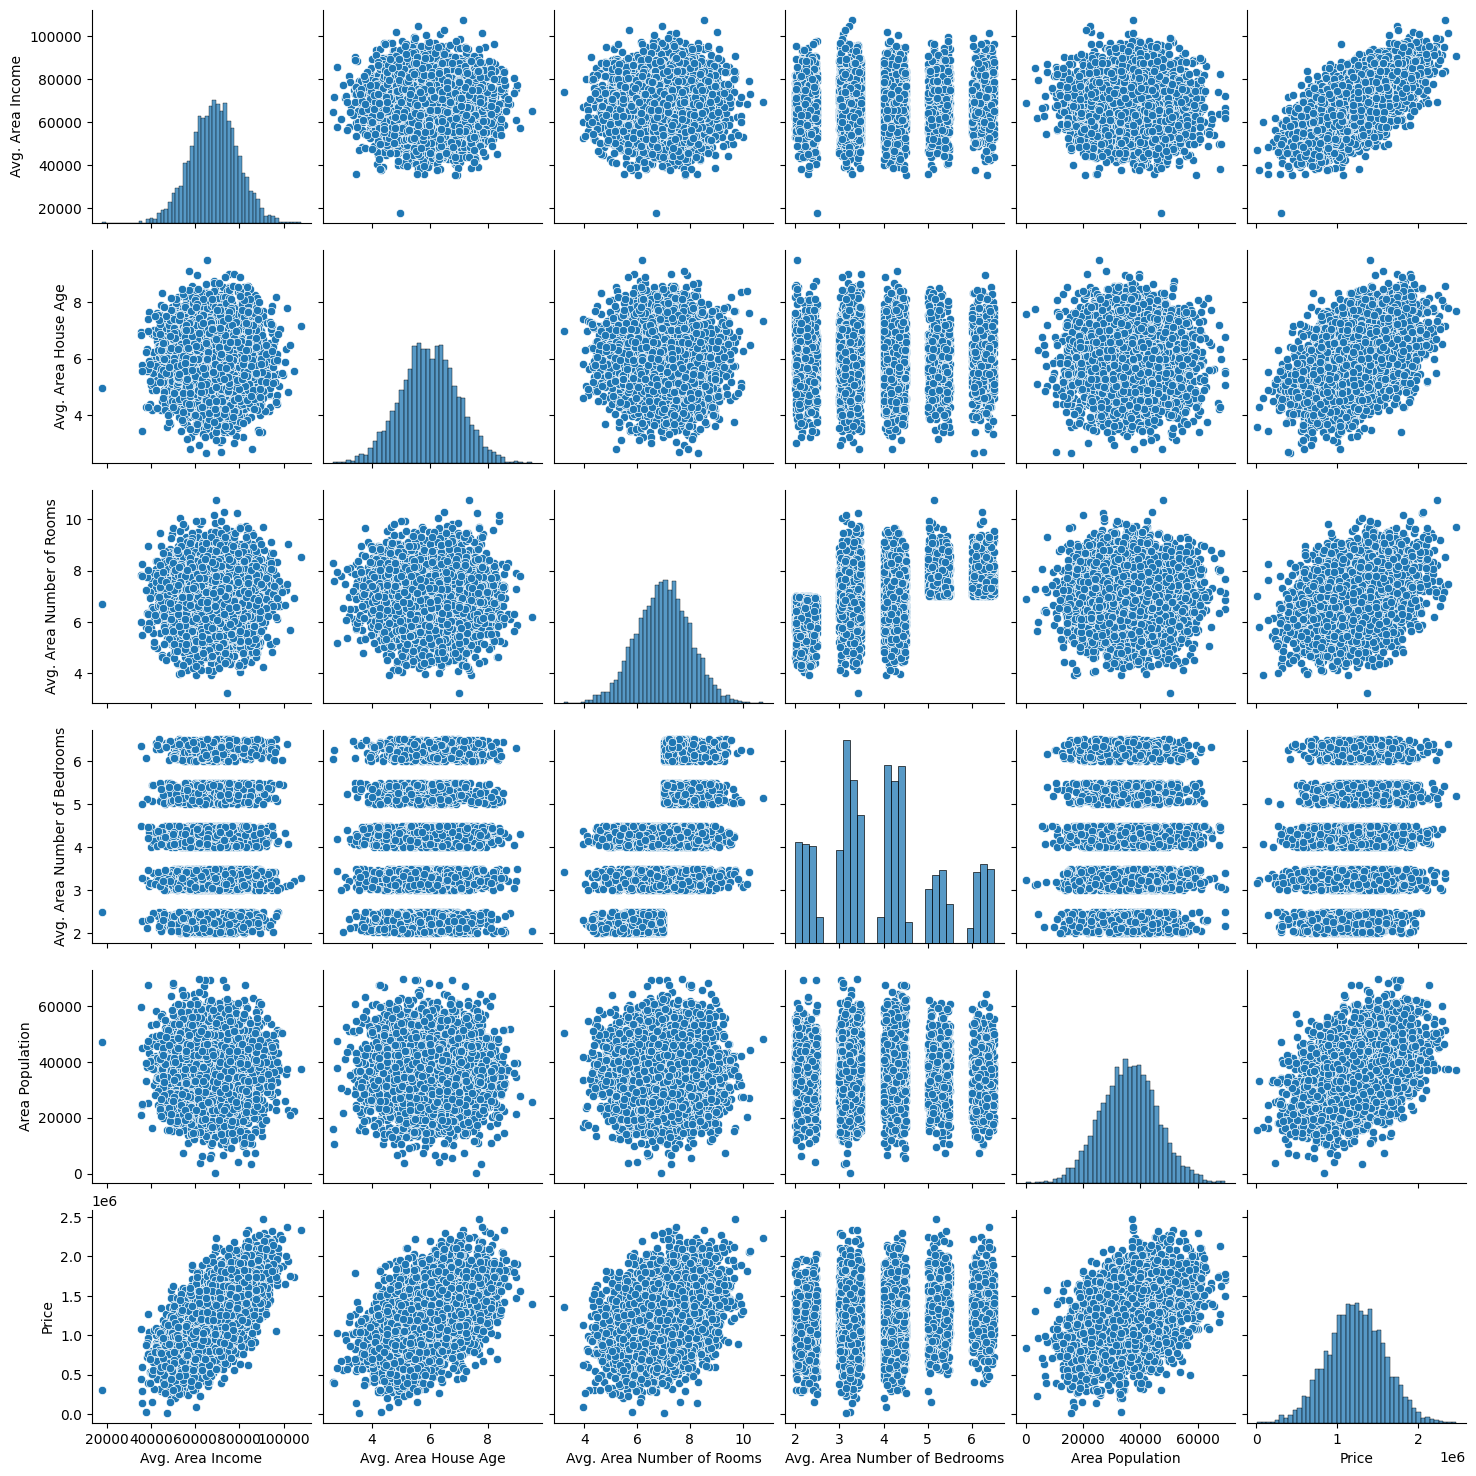

In [ ]:
sns.pairplot(USAhousing)


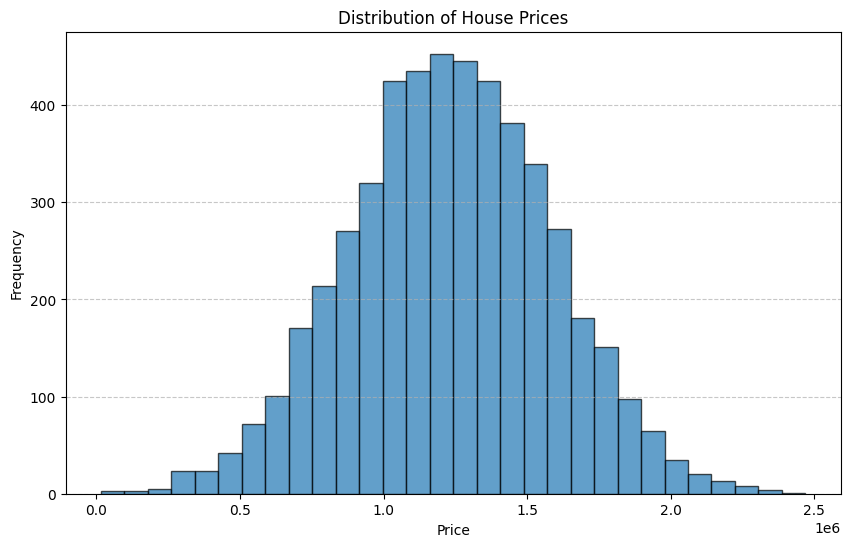

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(USAhousing['Price'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


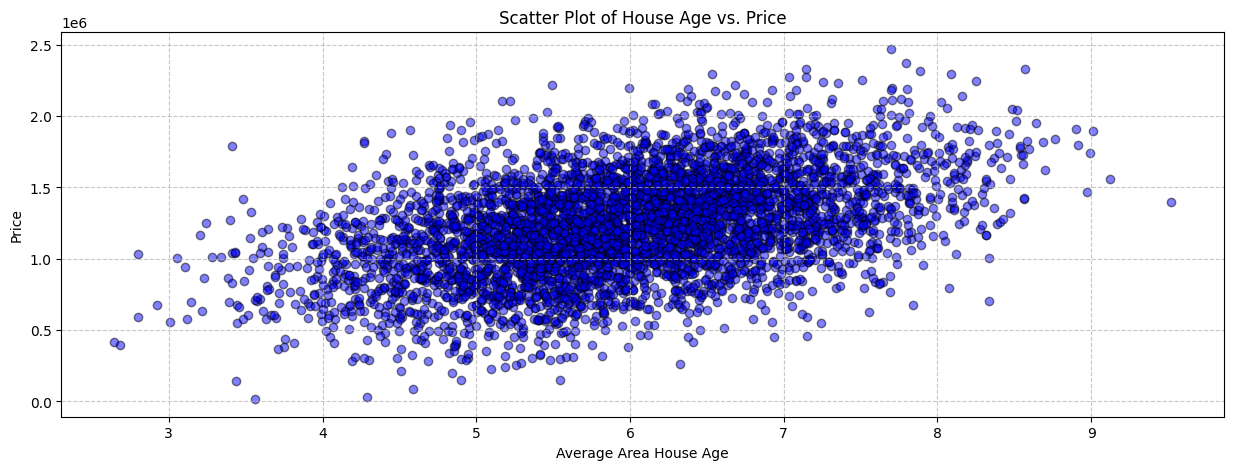

In [ ]:
plt.figure(figsize=(15, 5))  # Increase figure size
plt.scatter(x=USAhousing['Avg. Area House Age'], y=USAhousing['Price'], alpha=0.5, color='blue', edgecolors='black')
plt.xlabel('Average Area House Age')
plt.ylabel('Price')
plt.title('Scatter Plot of House Age vs. Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


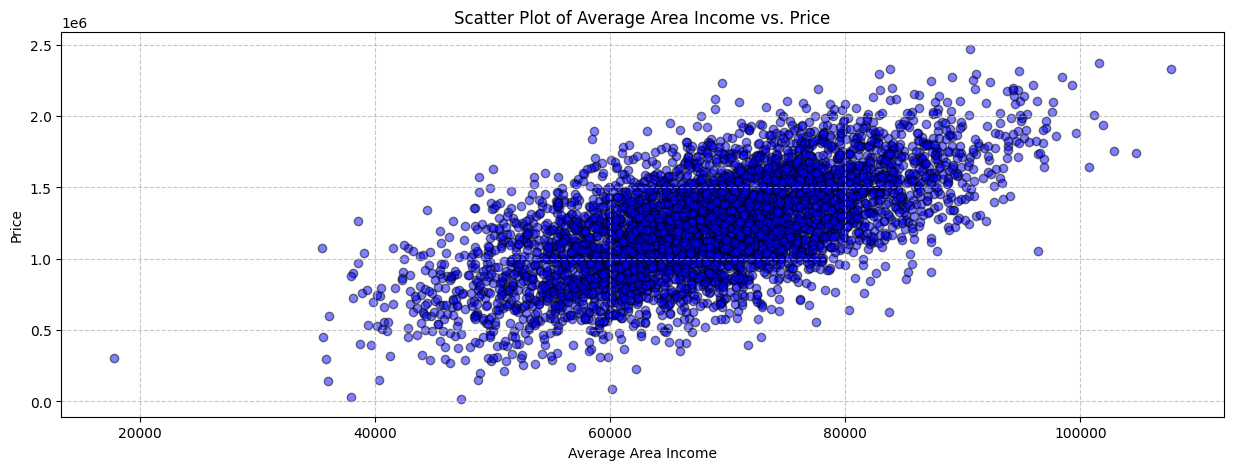

In [ ]:
plt.figure(figsize=(15, 5))  # Increase figure size
plt.scatter(x=USAhousing['Avg. Area Income'], y=USAhousing['Price'], alpha=0.5, color='blue', edgecolors='black')
plt.xlabel('Average Area Income')
plt.ylabel('Price')
plt.title('Scatter Plot of Average Area Income vs. Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
USAhousing.columns


Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [ ]:
X = USAhousing[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population']]
y = USAhousing['Price']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn import metrics
from sklearn.model_selection import cross_val_score

def cross_val(model):
    pred = cross_val_score(model, X, y, cv=10)
    return pred.mean()

def print_evaluate(true, predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2_square = metrics.r2_score(true, predicted)
    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)
    print('R2 Square', r2_square)
    print('__________________________________')

def evaluate(true, predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2_square = metrics.r2_score(true, predicted)
    return mae, mse, rmse, r2_square

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('std_scalar', StandardScaler())
])

X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)

## Linear regression

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)

LinearRegression()

In [ ]:
# print the intercept
print(lin_reg.intercept_)

1228219.1492415662


In [ ]:
coeff_df = pd.DataFrame(lin_reg.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Area Income,232679.724643
Avg. Area House Age,163841.046593
Avg. Area Number of Rooms,121110.555478
Avg. Area Number of Bedrooms,2892.815119
Area Population,151252.342377


In [ ]:
pred = lin_reg.predict(X_test)

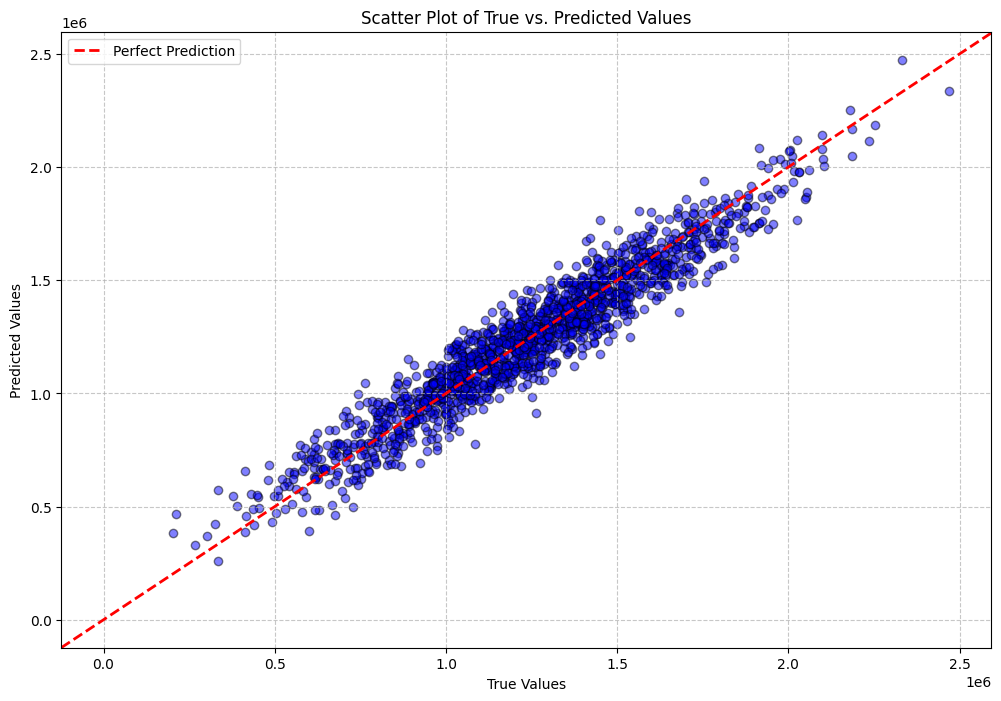

In [ ]:
df = pd.DataFrame({'True Values': y_test, 'Predicted Values': pred})

# Plotting with Matplotlib
plt.figure(figsize=(12, 8))  # Increase figure size
plt.scatter(df['True Values'], df['Predicted Values'], alpha=0.5, color='blue', edgecolors='black')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Scatter Plot of True vs. Predicted Values')
plt.axline((0, 0), slope=1, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')  # Reference line
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


<ipython-input-21-d3d4f16b4f2c>:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Error Values'], shade=True, color='blue', linewidth=2)


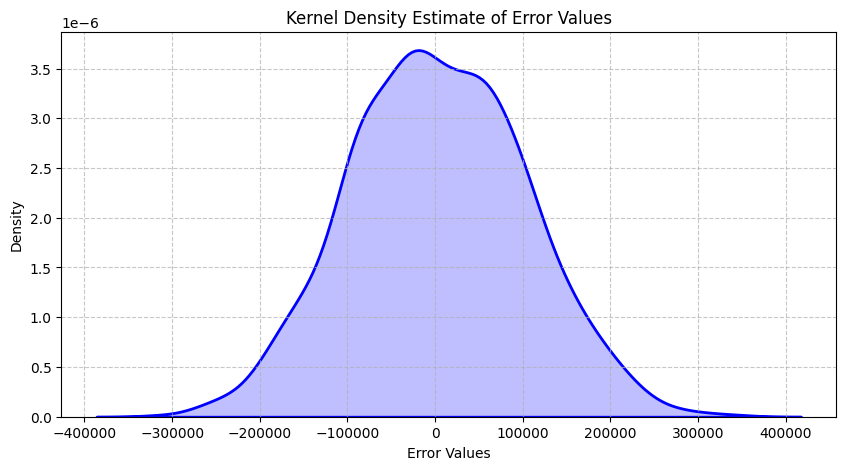

In [ ]:
df = pd.DataFrame({'Error Values': (y_test - pred)})

# Plotting KDE with Matplotlib & Seaborn
plt.figure(figsize=(10, 5))  # Increase figure size
sns.kdeplot(df['Error Values'], shade=True, color='blue', linewidth=2)
plt.xlabel('Error Values')
plt.ylabel('Density')
plt.title('Kernel Density Estimate of Error Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [ ]:
test_pred = lin_reg.predict(X_test)
train_pred = lin_reg.predict(X_train)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)
print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)

Test set evaluation:
_____________________________________
MAE: 81135.56609336878
MSE: 10068422551.40088
RMSE: 100341.52954485436
R2 Square 0.9146818498754016
__________________________________
Train set evaluation:
_____________________________________
MAE: 81480.49973174892
MSE: 10287043161.197224
RMSE: 101425.06180031257
R2 Square 0.9192986579075526
__________________________________


In [ ]:
results_df = pd.DataFrame(data=[["Linear Regression", *evaluate(y_test, test_pred) , cross_val(LinearRegression())]],
                          columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', "Cross Validation"])
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,81135.566093,1.006842e+10,100341.529545,0.914682,0.917379


In [ ]:
from sklearn.linear_model import RANSACRegressor

model = RANSACRegressor(max_trials=100)
model.fit(X_train, y_train)

test_pred = model.predict(X_test)
train_pred = model.predict(X_train)

print("test eval")
print_evaluate(y_test, test_pred)
print('='*20)
print('train eval')
print_evaluate(y_train, train_pred)

test eval
MAE: 82145.44442395376
MSE: 10317715163.904161
RMSE: 101576.15450441191
R2 Square 0.9125693854421772
__________________________________
train eval
MAE: 82240.40178768315
MSE: 10507814973.728542
RMSE: 102507.63373392512
R2 Square 0.9175667140157777
__________________________________


In [ ]:
results_df_2 = pd.DataFrame(data=[["Robust Regression", *evaluate(y_test, test_pred) , cross_val(RANSACRegressor())]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', "Cross Validation"])
results_df = pd.concat([results_df, results_df_2], ignore_index=True)
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,81135.566093,1.006842e+10,100341.529545,0.914682,0.917379
1,Robust Regression,82145.444424,1.031772e+10,101576.154504,0.912569,0.914157


In [ ]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=100, solver='cholesky', tol=0.0001, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

test_pred = model.predict(X_test)
train_pred = model.predict(X_train)

print_evaluate(y_test, test_pred)
print("-"*20)
print_evaluate(y_train, train_pred)

MAE: 81428.64835535336
MSE: 10153269900.892609
RMSE: 100763.43533689494
R2 Square 0.9139628674464607
__________________________________
--------------------
MAE: 81972.39058585507
MSE: 10382929615.143456
RMSE: 101896.66145239232
R2 Square 0.9185464334441484
__________________________________


In [ ]:
results_df_2 = pd.DataFrame(data=[["Ridge Regression", *evaluate(y_test, test_pred) , cross_val(Ridge())]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', "Cross Validation"])
results_df = pd.concat([results_df, results_df_2], ignore_index=True)
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,81135.566093,1.006842e+10,100341.529545,0.914682,0.917379
1,Robust Regression,82145.444424,1.031772e+10,101576.154504,0.912569,0.914157
2,Ridge Regression,81428.648355,1.015327e+10,100763.435337,0.913963,0.917379


In [ ]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.01, precompute=True, positive=True, selection='random', random_state=42)
model.fit(X_train, y_train)

test_pred = model.predict(X_test)
train_pred = model.predict(X_train)

print_evaluate(y_test, test_pred)
print_evaluate(y_train, train_pred)

MAE: 81135.69929443212
MSE: 10068453761.284801
RMSE: 100341.68506301258
R2 Square 0.9146815854079988
__________________________________
MAE: 81480.62910437852
MSE: 10287043197.206648
RMSE: 101425.06197782996
R2 Square 0.9192986576250604
__________________________________


In [ ]:
results_df_2 = pd.DataFrame(data=[["Lasso Regression", *evaluate(y_test, test_pred) , cross_val(Lasso())]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', "Cross Validation"])
results_df = pd.concat([results_df, results_df_2], ignore_index=True) # Changed append to concat to combine the two DataFrames.
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,81135.566093,1.006842e+10,100341.529545,0.914682,0.917379
1,Robust Regression,82145.444424,1.031772e+10,101576.154504,0.912569,0.914157
2,Ridge Regression,81428.648355,1.015327e+10,100763.435337,0.913963,0.917379
3,Lasso Regression,81135.699294,1.006845e+10,100341.685063,0.914682,0.917379


In [ ]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=0.1, l1_ratio=0.9, selection='random', random_state=42)
model.fit(X_train, y_train)

test_pred = model.predict(X_test)
train_pred = model.predict(X_train)

print_evaluate(y_test, test_pred)
print_evaluate(y_train, train_pred)

MAE: 81184.43147330944
MSE: 10078050168.470106
RMSE: 100389.49232100991
R2 Square 0.9146002670381437
__________________________________
MAE: 81577.88831531754
MSE: 10299274948.10146
RMSE: 101485.34351373828
R2 Square 0.9192027001474953
__________________________________


In [ ]:
results_df_2 = pd.DataFrame(data=[["Elastic Net Regression", *evaluate(y_test, test_pred) , cross_val(ElasticNet())]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', "Cross Validation"])
results_df = pd.concat([results_df, results_df_2], ignore_index=True) # Changed append to concat to combine the two DataFrames.
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,81135.566093,1.006842e+10,100341.529545,0.914682,0.917379
1,Robust Regression,82145.444424,1.031772e+10,101576.154504,0.912569,0.914157
2,Ridge Regression,81428.648355,1.015327e+10,100763.435337,0.913963,0.917379
3,Lasso Regression,81135.699294,1.006845e+10,100341.685063,0.914682,0.917379
4,Elastic Net Regression,81184.431473,1.007805e+10,100389.492321,0.914600,0.879545


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly_reg = PolynomialFeatures(degree=2)

X_train_2_d = poly_reg.fit_transform(X_train)
X_test_2_d = poly_reg.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_2_d, y_train)

test_pred = lin_reg.predict(X_test_2_d)
train_pred = lin_reg.predict(X_train_2_d)

print_evaluate(y_test, test_pred)
print_evaluate(y_train, train_pred)

MAE: 81174.51844119695
MSE: 10081983997.620695
RMSE: 100409.08324260656
R2 Square 0.914566932419506
__________________________________
MAE: 81363.0618562117
MSE: 10266487151.007814
RMSE: 101323.67517519198
R2 Square 0.9194599187853729
__________________________________


In [ ]:
results_df_2 = pd.DataFrame(data=[["Polynomail Regression", *evaluate(y_test, test_pred), 0]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', 'Cross Validation'])
results_df = pd.concat([results_df, results_df_2], ignore_index=True) # Changed append to concat to combine the two DataFrames.
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,81135.566093,1.006842e+10,100341.529545,0.914682,0.917379
1,Robust Regression,82145.444424,1.031772e+10,101576.154504,0.912569,0.914157
2,Ridge Regression,81428.648355,1.015327e+10,100763.435337,0.913963,0.917379
3,Lasso Regression,81135.699294,1.006845e+10,100341.685063,0.914682,0.917379
4,Elastic Net Regression,81184.431473,1.007805e+10,100389.492321,0.914600,0.879545
5,Polynomail Regression,81174.518441,1.008198e+10,100409.083243,0.914567,0.000000


In [ ]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(n_iter_no_change=250, penalty=None, eta0=0.0001, max_iter=100000)
sgd_reg.fit(X_train, y_train)

test_pred = model.predict(X_test)
train_pred = model.predict(X_train)

print_evaluate(y_test, test_pred)
print_evaluate(y_train, train_pred)

MAE: 81184.43147330944
MSE: 10078050168.470106
RMSE: 100389.49232100991
R2 Square 0.9146002670381437
__________________________________
MAE: 81577.88831531754
MSE: 10299274948.10146
RMSE: 101485.34351373828
R2 Square 0.9192027001474953
__________________________________


In [ ]:
results_df_2 = pd.DataFrame(data=[["Stochastic Gradient Descent", *evaluate(y_test, test_pred), 0]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', 'Cross Validation'])
results_df = pd.concat([results_df, results_df_2], ignore_index=True)
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,81135.566093,1.006842e+10,100341.529545,0.914682,0.917379
1,Robust Regression,82145.444424,1.031772e+10,101576.154504,0.912569,0.914157
2,Ridge Regression,81428.648355,1.015327e+10,100763.435337,0.913963,0.917379
3,Lasso Regression,81135.699294,1.006845e+10,100341.685063,0.914682,0.917379
4,Elastic Net Regression,81184.431473,1.007805e+10,100389.492321,0.914600,0.879545
5,Polynomail Regression,81174.518441,1.008198e+10,100409.083243,0.914567,0.000000
6,Stochastic Gradient Descent,81184.431473,1.007805e+10,100389.492321,0.914600,0.000000


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Activation, Dropout
from tensorflow.keras.optimizers import Adam

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

model = Sequential()

model.add(Dense(X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
# model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.2))

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1))

model.compile(optimizer=Adam(0.00001), loss='mse')

r = model.fit(X_train, y_train,
              validation_data=(X_test,y_test),
              batch_size=1,
              epochs=100)

Epoch 1/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 1639359184896.0000 - val_loss: 1658104578048.0000
Epoch 2/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 1652021133312.0000 - val_loss: 1656059330560.0000
Epoch 3/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 1652421558272.0000 - val_loss: 1646966734848.0000
Epoch 4/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 1634602319872.0000 - val_loss: 1620400406528.0000
Epoch 5/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - loss: 1575795556352.0000 - val_loss: 1560571674624.0000
Epoch 6/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 1497626836992.0000 - val_loss: 1446122881024.0000
Epoch 7/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 1371797192704.0000 - val_loss: 1257153363968.0000
Epoch 8/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 1197387153408.0000 - val_loss: 988414148608.0000
Epoch 9/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 889246711808.0000 - val_l

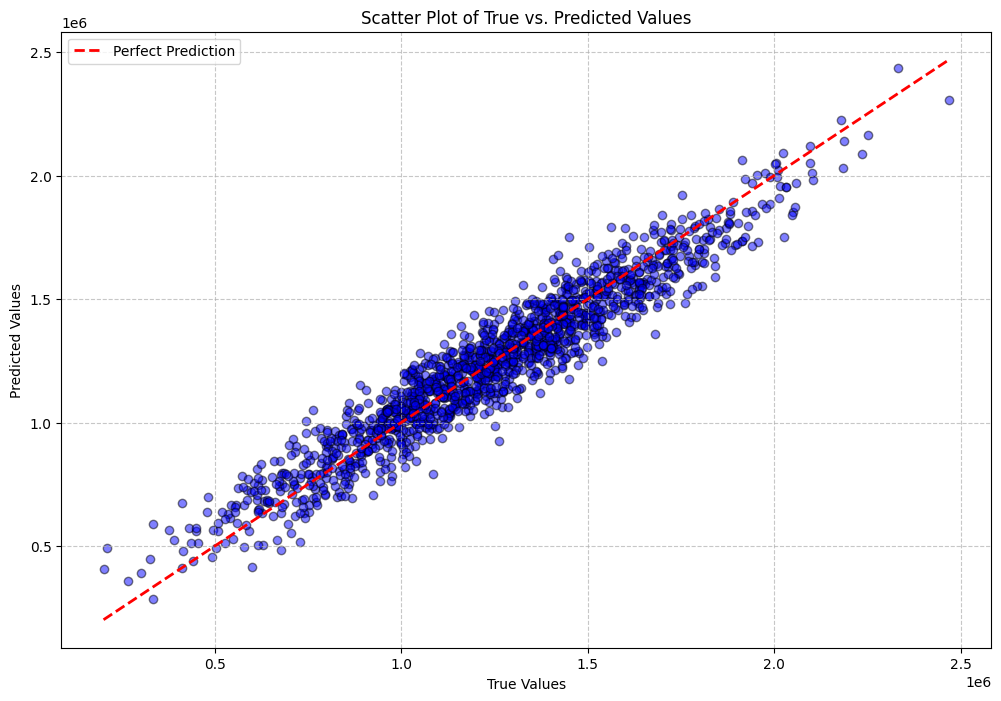

In [ ]:
df = pd.DataFrame({'True Values': y_test, 'Predicted Values': pred})


plt.figure(figsize=(12, 8))  # Increase figure size
plt.scatter(df['True Values'], df['Predicted Values'], alpha=0.5, color='blue', edgecolors='black')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Scatter Plot of True vs. Predicted Values')
plt.grid(True, linestyle='--', alpha=0.7)

# Adding a reference line (y = x) for perfect predictions
min_val = min(df['True Values'].min(), df['Predicted Values'].min())
max_val = max(df['True Values'].max(), df['Predicted Values'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.legend()
plt.show()

In [ ]:
pd.DataFrame(r.history)


,loss,val_loss
0,1.635959e+12,1.658105e+12
1,1.635143e+12,1.656059e+12
2,1.630218e+12,1.646967e+12
3,1.613520e+12,1.620400e+12
4,1.572057e+12,1.560572e+12
...,...,...
95,2.009785e+10,1.833013e+10
96,2.016840e+10,1.808415e+10
97,1.967344e+10,1.795422e+10
98,1.953594e+10,1.781946e+10


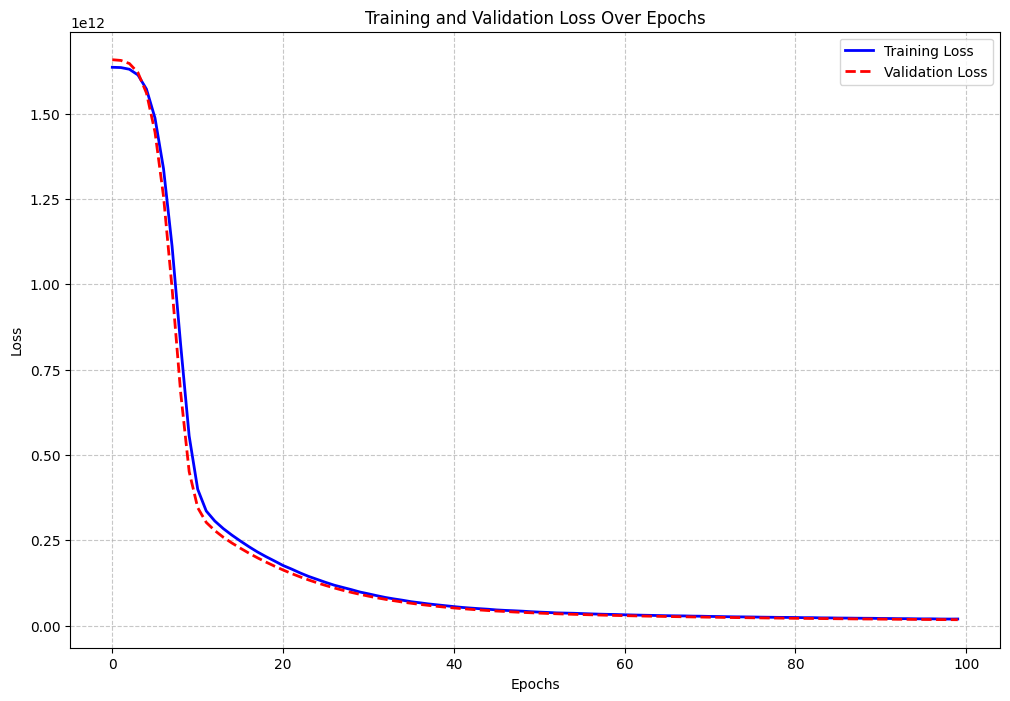

In [ ]:
df = pd.DataFrame(r.history)

# Plotting with Matplotlib
plt.figure(figsize=(12, 8))  # Increase figure size
plt.plot(df.index, df['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(df.index, df['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)

# Labels and title
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Show plot
plt.show()

In [ ]:
test_pred = model.predict(X_test)
train_pred = model.predict(X_train)

print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, test_pred)

print('Train set evaluation:\n_____________________________________')
print_evaluate(y_train, train_pred)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test set evaluation:
_____________________________________
MAE: 104137.20999122167
MSE: 17574990845.978615
RMSE: 132570.70131057847
R2 Square 0.8510724296898906
__________________________________
Train set evaluation:
_____________________________________
MAE: 106325.83407987631
MSE: 18692579421.398037
RMSE: 136720.8082970476
R2 Square 0.8533576438984316
__________________________________


In [ ]:
results_df_2 = pd.DataFrame(data=[["Artficial Neural Network", *evaluate(y_test, test_pred), 0]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', 'Cross Validation'])
results_df = pd.concat([results_df, results_df_2], ignore_index=True)
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,81135.566093,1.006842e+10,100341.529545,0.914682,0.917379
1,Robust Regression,81409.060755,1.017228e+10,100857.744645,0.913802,0.912536
2,Ridge Regression,81428.648355,1.015327e+10,100763.435337,0.913963,0.917379
3,Lasso Regression,81135.699294,1.006845e+10,100341.685063,0.914682,0.917379
4,Elastic Net Regression,81184.431473,1.007805e+10,100389.492321,0.914600,0.879545
5,Polynomail Regression,81174.518441,1.008198e+10,100409.083243,0.914567,0.000000
6,Stochastic Gradient Descent,81184.431473,1.007805e+10,100389.492321,0.914600,0.000000
7,Artficial Neural Network,93136.308628,1.408100e+10,118663.409141,0.880680,0.000000


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=1000)
rf_reg.fit(X_train, y_train)

test_pred = rf_reg.predict(X_test)
train_pred = rf_reg.predict(X_train)

print_evaluate(y_test, test_pred)
print_evaluate(y_train, train_pred)

MAE: 94192.84880309172
MSE: 14117474938.509481
RMSE: 118816.98085084253
R2 Square 0.8803708485579579
__________________________________
MAE: 35354.15770475193
MSE: 1988494217.913881
RMSE: 44592.53545060968
R2 Square 0.984400361735233
__________________________________


In [ ]:
results_df_2 = pd.DataFrame(data=[["Random Forest Regressor", *evaluate(y_test, test_pred), 0]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', 'Cross Validation'])
results_df = pd.concat([results_df, results_df_2], ignore_index=True)
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,81135.566093,1.006842e+10,100341.529545,0.914682,0.917379
1,Robust Regression,81409.060755,1.017228e+10,100857.744645,0.913802,0.912536
2,Ridge Regression,81428.648355,1.015327e+10,100763.435337,0.913963,0.917379
3,Lasso Regression,81135.699294,1.006845e+10,100341.685063,0.914682,0.917379
4,Elastic Net Regression,81184.431473,1.007805e+10,100389.492321,0.914600,0.879545
5,Polynomail Regression,81174.518441,1.008198e+10,100409.083243,0.914567,0.000000
6,Stochastic Gradient Descent,81184.431473,1.007805e+10,100389.492321,0.914600,0.000000
7,Artficial Neural Network,93136.308628,1.408100e+10,118663.409141,0.880680,0.000000
8,Random Forest Regressor,94192.848803,1.411747e+10,118816.980851,0.880371,0.000000


In [ ]:
from sklearn.svm import SVR

svm_reg = SVR(kernel='rbf', C=1000000, epsilon=0.001)
svm_reg.fit(X_train, y_train)

test_pred = svm_reg.predict(X_test)
train_pred = svm_reg.predict(X_train)

print_evaluate(y_test, test_pred)
print_evaluate(y_train, train_pred)

MAE: 87205.73051021632
MSE: 11720932765.275513
RMSE: 108263.25676458987
R2 Square 0.9006787511983232
__________________________________
MAE: 73692.5684807321
MSE: 9363827731.411339
RMSE: 96766.87310960988
R2 Square 0.9265412370487783
__________________________________


In [ ]:
results_df_2 = pd.DataFrame(data=[["SVM Regressor", *evaluate(y_test, test_pred), 0]],
                            columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Square', 'Cross Validation'])
results_df = pd.concat([results_df, results_df_2], ignore_index=True)
results_df

,Model,MAE,MSE,RMSE,R2 Square,Cross Validation
0,Linear Regression,81135.566093,1.006842e+10,100341.529545,0.914682,0.917379
1,Robust Regression,81409.060755,1.017228e+10,100857.744645,0.913802,0.912536
2,Ridge Regression,81428.648355,1.015327e+10,100763.435337,0.913963,0.917379
3,Lasso Regression,81135.699294,1.006845e+10,100341.685063,0.914682,0.917379
4,Elastic Net Regression,81184.431473,1.007805e+10,100389.492321,0.914600,0.879545
5,Polynomail Regression,81174.518441,1.008198e+10,100409.083243,0.914567,0.000000
6,Stochastic Gradient Descent,81184.431473,1.007805e+10,100389.492321,0.914600,0.000000
7,Artficial Neural Network,93136.308628,1.408100e+10,118663.409141,0.880680,0.000000
8,Random Forest Regressor,94192.848803,1.411747e+10,118816.980851,0.880371,0.000000
9,SVM Regressor,87205.730510,1.172093e+10,108263.256765,0.900679,0.000000


<Axes: ylabel='Model'>

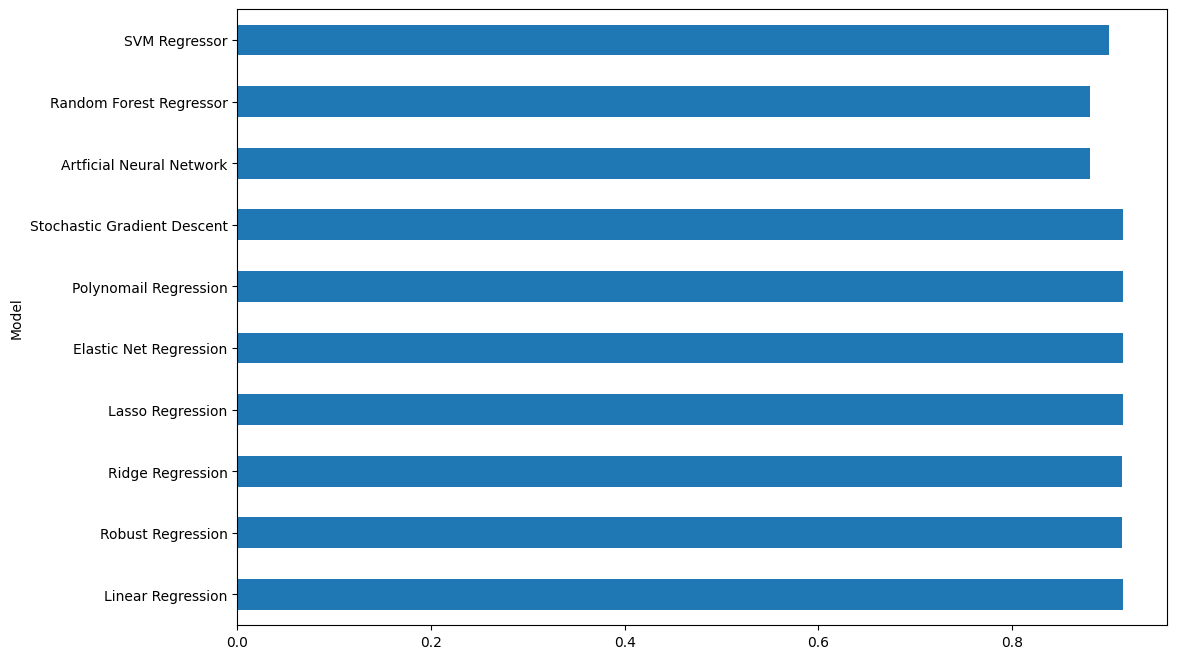

In [ ]:
results_df.set_index('Model', inplace=True)
results_df['R2 Square'].plot(kind='barh', figsize=(12, 8))